# Protein-peptide modeling tutorial using a local version of HADDOCK3


---
## Introduction

In this tutorial, we will focus on docking the N-terminal peptide of p53 to the mouse MDM2 protein. The tumor suppressor p53 is often referred to as the guardian of the genome because of its central role in preventing tumor development. As a transcription factor, it regulates the cell cycle and can induce DNA repair or apoptosis in response to cellular stress. MDM2, an E3 ubiquitin ligase, is a key negative regulator of p53: by binding to its N-terminal transactivation domain (TAD) peptide, it inhibits p53 activity and promotes its degradation. The p53–MDM2 interaction is therefore of major biological and medical importance.

For the mouse MDM2–p53 system, no experimental structure of the complex is available. Modelling such interactions is challenging because protein–peptide docking is generally more difficult than protein–protein docking. This is primarily due to the intrinsic flexibility of peptides, which allows them to adopt multiple conformations, complicating prediction of the bound state.

In this tutorial, we will use HADDOCK3 to model the MDM2–p53 complex. Docking will be guided by pre-defined restraints derived from known interfaces of the human homolog of MDM2. As input structures, we will use an AlphaFold model of mouse MDM2 together with an ensemble of idealized peptide conformations. This combination will allow us to sample and predict plausible binding modes for the p53 peptide. Since no experimentally solved structure is available this complex, the human MDM2–p53 complex will be used as a reference for assessing the docking results (PDB ID: [1YCR](https://www.rcsb.org/structure/1YCR)).


<figure style="text-align: center;">
  <img
src="https://www.bonvinlab.org/education/HADDOCK3/HADDOCK3-protein-peptide/png/1ycr_pretty.png">
</figure>


---
# **A brief introduction to HADDOCK3**

HADDOCK3 is the next generation integrative modelling software in the
long-lasting HADDOCK project. It represents a complete rethinking and rewriting
of the HADDOCK2.X series, implementing a new way to interact with HADDOCK and
offering new features to users who can now define custom workflows.

In the previous HADDOCK2.x versions, users had access to a highly
parameterisable yet rigid simulation pipeline composed of three steps:
`rigid-body docking (it0)`, `semi-flexible refinement (it1)`, and `final refinement (itw)`.

<figure style="text-align: center;">
<img width="75%" src="https://bonvinlab.org/education/HADDOCK3/HADDOCK3-antibody-antigen/HADDOCK2-stages.png">
</figure>

In HADDOCK3, users have the freedom to configure docking workflows into
functional pipelines by combining the different HADDOCK3 modules, thus
adapting the workflows to their projects. HADDOCK3 has therefore developed to
truthfully work like a puzzle of many pieces (simulation modules) that users can
combine freely. To this end, the old HADDOCK machinery has been modularized,
and several new modules added, including third-party software additions. As a
result, the modularization achieved in HADDOCK3 allows users to duplicate steps
within one workflow (e.g., to repeat twice the `it1` stage of the HADDOCK2.x
rigid workflow).
Note that, for simplification purposes, at this time, not all functionalities of
HADDOCK2.x have been ported to HADDOCK3, which does not (yet) support NMR RDC,
PCS and diffusion anisotropy restraints, cryo-EM restraints and coarse-graining.
Any type of information that can be converted into ambiguous interaction
restraints can, however, be used in HADDOCK3, which also supports the
*ab initio* docking modes of HADDOCK.

<figure style="text-align: center;">
<img width="75%" src="https://bonvinlab.org/education/HADDOCK3/HADDOCK3-antibody-antigen/HADDOCK3-workflow-scheme.png">
</figure>

To keep HADDOCK3 modules organized, we catalogued them into several
categories. However, there are no constraints on piping modules of different
categories.

The main module categories are "topology", "sampling", "refinement",
"scoring", and "analysis". There is no limit to how many modules can belong to a
category. Modules are added as developed, and new categories will be created
if/when needed. You can access the HADDOCK3 documentation page for the list of
all categories and modules. Below is a summary of the available modules:

* **Topology modules**
    * `topoaa`: *generates the all-atom topologies for the CNS engine.*
* **Sampling modules**
    * `rigidbody`: *Rigid body energy minimization with CNS (`it0` in haddock2.x).*
    * `lightdock`: *Third-party glow-worm swam optimization docking software.*
* **Model refinement modules**
    * `flexref`: *Semi-flexible refinement using a simulated annealing protocol through molecular dynamics simulations in torsion angle space (`it1` in haddock2.x).*
    * `emref`: *Refinement by energy minimisation (`itw` EM only in haddock2.4).*
    * `mdref`: *Refinement by a short molecular dynamics simulation in explicit solvent (`itw` in haddock2.X).*
* **Scoring modules**
    * `emscoring`: *scoring of a complex performing a short EM (builds the topology and all missing atoms).*
    * `mdscoring`: *scoring of a complex performing a short MD in explicit solvent + EM (builds the topology and all missing atoms).*
* **Analysis modules**
    * `alascan`: *Performs a systematic (or user-define) alanine scanning mutagenesis of interface residues.*
    * `caprieval`: *Calculates CAPRI metrics (i-RMSD, l-RMSD, Fnat, DockQ) with respect to the top-scoring model or reference structure if provided.*
    * `clustfcc`: *Clusters models based on the fraction of common contacts (FCC)*
    * `clustrmsd`: *Clusters models based on pairwise RMSD matrix calculated with the `rmsdmatrix` module.*
    * `contactmap`: *Generate contact matrices of both intra- and intermolecular contacts and a chordchart of intermolecular contacts.*
    * `rmsdmatrix`: *Calculates the pairwise RMSD matrix between all the models generated in the previous step.*
    * `ilrmsdmatrix`: *Calculates the pairwise interface-ligand-RMSD (il-RMSD) matrix between all the models generated in the previous step.*
    * `seletop`: *Selects the top N models from the previous step.*
    * `seletopclusts`: *Selects the top N clusters from the previous step.*

The HADDOCK3 workflows are defined in simple configuration text files, similar to the TOML format but with extra features.
Contrary to HADDOCK2.X which follows a rigid (yet highly parameterisable)
procedure, in HADDOCK3, you can create your own simulation workflows by
combining a multitude of independent modules that perform specialized tasks.



---
# **Software and data setup**

In order to follow this tutorial we will start Jupyter session in Colab or other resources, install haddock3 and download the data for the tutorial.

To run this tutorial on Colab we recommend changing the runtime type to use one of the TPU option, which will give you access to more cores. The haddock3 docking run described in this tutorial should complete in about 15 minutes.

For this follow the following steps (comment out the `pip install haddock3` line if you already have a working installation):

In [1]:
#@title 1. Install haddock3, BioPython and py3Dmol
#@markdown Execute this cell to download the required packages.
!pip install haddock3==2026.7.0 --quiet
!pip install py3Dmol --quiet
!pip install BioPython --quiet

In [2]:
#@title 1. Download tutorial data and setup environment
#@markdown Execute this cell to download the tutorial data.
!wget https://surfdrive.surf.nl/public.php/dav/files/3GE8k07b8EtuVK8 -O HADDOCK3-protein-peptide.zip
!unzip HADDOCK3-protein-peptide.zip
!\rm HADDOCK3-protein-peptide.zip
import os
from pathlib import Path
BASE_DIR = Path.cwd()
PROJECT_NAME = 'HADDOCK3-protein-peptide'
PROJECT_DIR = BASE_DIR / PROJECT_NAME
os.chdir(PROJECT_DIR)

--2026-08-25 09:59:58--  https://surfdrive.surf.nl/public.php/dav/files/3GE8k07b8EtuVK8
surfdrive.surf.nl (surfdrive.surf.nl) çözümleniyor... 145.107.56.140, 145.107.8.140
surfdrive.surf.nl (surfdrive.surf.nl)[145.107.56.140]:443 bağlanılıyor... bağlantı kuruldu.
HTTP isteği gönderildi, yanıt bekleniyor... 200 OK
Uzunluk: 241474807 (230M) [application/zip]
Kayıt yeri: `HADDOCK3-protein-peptide.zip'

HADDOCK3-protein-pe 100%[===================>] 230,29M   521KB/s    içinde 10m 58s

2026-08-25 10:10:57 (359 KB/s) - `HADDOCK3-protein-peptide.zip' kaydedildi [241474807/241474807]

Archive:  HADDOCK3-protein-peptide.zip
replace HADDOCK3-protein-peptide/workflows/protein_peptide_docking_best_practices.cfg? [y]es, [n]o, [A]ll, [N]one, [r]ename: ^C


ecompressing the file will create the `HADDOCK3-protein-peptide` directory with the following subdirectories and items:

* `pdbs`: Contains the pre-processed PDB files, both the docking input, and bound reference.
* `restraints`: Contains the interface information and the correspond restraint files for HADDOCK.
* `runs`: : Contains pre-computed docking results for each scenario defined in `workflows` directory, useful for comparison with your own run, or if you prefer to skip the computationally intensive steps.
* `scripts`: Contains two analysis scripts used in this tutorial.
* `workflows`: Contains HADDOCK3 workflow used for the docking.
----


---
# Preparing PDB files for docking

The accuracy of docking results in HADDOCK3 depends heavily on the quality of the input structures. In this section, we will prepare the PDB files of the protein and peptide for docking. The protein model is created using AlphaFold, and multiple conformations of the peptide are generated using [PyMOL](https://www.pymol.org/). We will use `pdb-tools`to manipulate the structures to make them HADDOCK-ready, e.g. to renumber residues, assign chain IDs and generate ensemble file. By default, `pdb-tools` are being installed on your machine together with haddock3. `pdb-tools` documentation is available [here](https://www.bonvinlab.org/pdb-tools/).

Note: that pdb-tools is also available as a [web service](https://wenmr.science.uu.nl/pdbtools/).

Note: Before starting to work on the tutorial, make sure to activate an appropriate virtual environment. If haddock3 was installed using `conda`run the following cell:



In [58]:
! conda activate haddock3


CondaError: Run 'conda init' before 'conda activate'



For more information about accepted file formats and preparation steps, refer to the [HADDOCK3 user manual – structure requirements](https://www.bonvinlab.org/haddock3-user-manual/structure_requirements.html).

# Preparing the protein structure

One of the easiest ways to find information about a protein, including its structure, is to explore the UniProt database. [UniProt](https://www.uniprot.org/) provides detailed protein sequence and functional data, including annotations, sequence features, and links to structural information.

__*Open the UniProt home page (https://www.uniprot.org) and search for “mouse MDM2”.*__

You should see the entry “P23804 · MDM2_MOUSE”. Feel free to take you time and explore the page.

__*Click on the section ‘Structure’ (left side of the page) or scroll down until you reach it.*__

This protein has no experimentally solved 3D structure, only AlphaFold model is available. This model model covers the full-length sequence of MDM2, but for docking we only need its p53-binding domain. This domain corresponds to residues 26 to 109. Check out [Family & Domains section](https://www.uniprot.org/uniprotkb/P23804/entry#family_and_domains) of the UniProt to see all other regions of the protein. The remaining regions, particularly the disordered one, are known not to interact with the peptide, so it’s a good idea remove them, both to make the docking problem easier, and to reduce the computational cost of the docking.

__*Click the download icon at the right end of the yellow ribbon to obtain this model. At the time this tutorial was created, the file name was AF-P23804-F1-model_v6.pdb. With future updates to the AlphaFold Database, the version tag “v6” will change.*__

__*Move downloaded model AF-P23804-F1-model_v4.pdb to your work directory, e.g. HADDOCK3-protein-peptide/*__

To prepare this model for docking, we will:

1 Keep only the coordinates lines, i.e and remove REMARK and other irrelevant lines (`pdb_keepcoord`),
2. Keep only residues of interest (`pdb_selres`),
3. Assign chain ID (`pdb_chain`), and
4. Apply pdb-formatting to the file (`pdb_tidy`).



In [59]:
! pdb_keepcoord AF-P23804-F1-model_v6.pdb | pdb_selres -26:109 | pdb_chain -A | pdb_tidy -strict > AF_MDM2_26_109.pdb



*Note* when working with the experimentally solved structures, preparation algorithm would be different, e.g. we would use `pdb_delhetatm` and `pdb_selaltloc`.

*Note* `pdb_tidy` attempts to correct formatting only, e.g. ensure each line is long enough (padded with spaces), not the actual content of the PDB file.

You can compare the structure `AF_MDM2_26_109.pdb` with initial AlphaFold model `AF-P23804-F1-model_v4.pdb` by running the following command: 

In [7]:
from haddock.libs.libnotebooks import align_full
#@title View the top ranking model from the best cluster
#@markdown It will be shown superimposed onto the reference structure fitted only on the second receptor and the DNA
# Define paths to PDB files to be aligned
# Here we are overlaying the reference and 1st model from the 1st cluster
path1 = PROJECT_DIR / "AF_MDM2_26_109.pdb"
path2 = PROJECT_DIR / "AF-P23804-F1-model_v6.pdb"

# Align molecules by chain and display the result.
# For the full alignement put all chain IDs in the `chains` variable.
align_full(str(path1), str(path2), chains = ['A'])

Atoms for alignment - Model 1: {'A': 84}, Total: 84
Atoms for alignment - Model 2: {'A': 489}, Total: 489
Model 1: chain A in red
Model 2: chain A in blue
Using 84 atom pairs for alignment
Whole molecule alignment RMSD: 16.470 Å
Chain A RMSD: 16.470 Å


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

 # Preparing peptide structure

 When modelling peptides with no experimental structure available, a common approach is to perform a molecular dynamics (MD) simulation and cluster the trajectory to capture the peptide’s conformational variability. This process is computationally expensive and can be challenging in the absence of MD experience. A simpler alternative is to generate several idealized peptide conformations. While less robust, this approach still indirectly accounts for peptide’s flexibility to some degree, and that can be just enough to build a model of acceptable quality.

The sequence of interest (residues 18-32 of the p53_mouse) is:

`SQETFSGLWKLLPPE`
Note this sequence can be found on the UniProt page for `P02340 · P53_MOUSE`, under the ‘Structure’ section.

We will generate three idealized peptide conformations: α-helix, β-sheet, and polyproline II (ppII). This can be done using PyMOL’s built-in fab command. To see a usage example:

NOT FINISHED!!!!!!


---
# Defining restraints for docking

HADDOCK relies on restraints to guide the sampling process during docking. Several types of restraints can be defined, including unambiguous and ambiguous distance restraints (AIRs). These restraints are specified using CNS ([Crystallography & NMR System](https://cns-online.org/v1.3/) syntax, which defines two atom selections and a distance range that must be satisfied. If a restraint is not fulfilled, a penalty is applied to the HADDOCK scoring function, lowering the rank of the model that violate the restraints.

To simplify, restraints are defined by specifying two types of residue selections, active and passive, together with a distance range that must be satisfied. __Active__ residues are those known to be present in the interface and solvent accessible. If an active residues is not in the interface of a model, then energetic penalty is applied. __Passive__ residues are typically all solvent-accessible surface neighbors of active residues, or other atoms that may plausibly be involved in the interaction. Yet if a passive residue is not part of the interface - no penalty is applied.

A distance restraint is then expressed using CNS syntax as follows:

`assign (selection_1) (selection_2) target_distance, lower_margin, upper_margin`

The allowed range for the distance is then:

`target_distance - lower_margin  ≤  distance  ≤  target_distance + upper_margin`

Selections can be customized using keywords such as `segid` (chain ID), `resid` (residue number), and `name` (atom name). These can be combined with logical operators AND, OR to construct more complex definitions. Please refer for that to the [online CNS manual](https://cns-online.org/v1.3/) for more info.

AIRs file (`.tbl`) can be generated using the `haddock3-restraints` command line tool (installed with haddock3) or a version [web version](https://wenmr.science.uu.nl/haddock-restraints). We will explain how to use this tool shortly, but first we need to identify which residues participate in the interaction - both active and passive.

# Defining active residues for protein

[ARCTIC-3D](https://wenmr.science.uu.nl/login) is a data-mining tool that clusters all known interfaces of a protein, grouping similar interaction sites into residue sets that are likely to participate in binding. For mouse MDM2, no structural information is currently available, however, such data exists for its human homolog. To define plausible active residues in mouse MDM2, we applied ARCTIC-3D to the human protein and transferred the results onto mouse variant. Resulting residues were filtered based on their solvent accessibility:

`54 55 58 59 62 67 72 73 93 94 100 `

For more details, take a look at the bonus section: How to use [ARCTIC-3D](https://www.bonvinlab.org/education/HADDOCK3/HADDOCK3-protein-peptide/#bonus-how-to-use-arctic-3d-to-predict-interface-residues)?

Let’s visualize predicted active residues on the protein structure we prepared:


In [8]:
#@title Visualize a single model in surface representation highlighting the binding site
import py3Dmol
import gzip
import os

view = py3Dmol.view(width=800, height=600)

pdb_file_path = "AF_MDM2_26_109.pdb"

if not os.path.exists(pdb_file_path):
    print(f"Error: File not found at {pdb_file_path}")

else:
    if pdb_file_path.endswith(".gz"):
        with gzip.open(pdb_file_path, "rt") as file:
            pdb_data = file.read()
    else:
        with open(pdb_file_path, "r") as file:
            pdb_data = file.read()

    view.addModelsAsFrames(pdb_data, "pdb")
    view.setStyle({'cartoon': {'color': 'green'}})
    view.addStyle({'stick': {'color': 'green'}})
    view.addStyle({'resi': [54, 55, 58, 59, 62, 67, 72, 73, 93, 94, 100]},{'cartoon':{'color':'red'}})
    view.addStyle({'resi': [54, 55, 58, 59, 62, 67, 72, 73, 93, 94, 100]},{'stick':{'color':'red'}})
    view.addSurface(py3Dmol.SAS, {'opacity':0.4, 'color':'green'})
    view.zoomTo()
    view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

# Defining passive residues for peptide

Since no experimental data or reliable predictions are available to identify which peptide residues are directly involved in the interface, we do not define any active residues for the peptide. Instead, we assign all peptide residues as passive, allowing HADDOCK to explore possible interaction sites during docking:

`1 2 3 4 5 6 7 8 9 10 11 12 13 14 15`

# Using haddock3-restraints to generate restraint file

To generate AIRs with `haddock3-restraints`, you need to use its sub-option `active_passive_to_ambig` and provide an `.act-pass` file that lists the active and/or passive residues for each docking partner. This file has the following syntax:

Active residues are written on the first line, separated by spaces.
Passive residues are written on the second line, also separated by spaces. If no active residues are defined, the first line should remain empty. The same applies to the second line if no passive residues are used.

In our case, this is the file for MDM2, `protein-AR3D-active.act-pass`:

`54 55 58 59 62 67 72 73 93 94 100`

And the file for p53, `peptide-ens-passive.act-pass`:


`1 2 3 4 5 6 7 8 9 10 11 12 13 14 15`

Create these files manually, or access pre-made ones in `restraints/`.

This files can then be used as input to `haddock3-restraints active_passive_to_ambig`to generate the restraint file:

In [15]:
! haddock3-restraints active_passive_to_ambig protein-AR3D-active.act-pass peptide-ens-passive.act-pass > protein-peptide_ambig.tbl

*Note* that *passive* residues on partner 1 should only be defined if *active* residues have been specified on partner 2, and vice versa.

Typically, active residues are complemented by nearby passive residues on the same molecule to account for uncertainties in the binding site definition. But if there’s no active residues on the partner 2 - passive residues of partner 1 have nothing to interact with. In this tutorial, active residues are defined only for MDM2, while no active residues are defined for the peptide. Thus, we only assign the peptide residues as passive.



# Restraints validation

After generating `protein-peptide_ambig.tbl``, one can validate the syntax of this file using:

In [16]:
! haddock3-restraints validate_tbl protein-peptide_ambig.tbl --silent

If the file is valid, there will be no output.

*Note*: This command checks only the file’s formatting, not the biological correctness or content of the restraints.

# Setting up the docking with HADDOCK3

Having now all the required input files and restraints, we can proceed with the docking setup!

## HADDOCK3 workflow definition

The first step is to create a HADDOCK3 configuration file that will define the docking workflow. We will follow a classic HADDOCK workflow that include topology generation, rigid-body minimization, semi-flexible interface refinement, and final refinement, followed by model selection, clustering, and evaluation. We will include multiple evaluation instances (`caprieval` module) to compare models to either the best scoring model (if no reference is given) or a reference structure, which in our case we have at hand. This will allow us to assess the performance of the protocol.

The modules included in this workflow are:

* `topoaa`: Generates the topologies for the CNS engine and builds missing atoms.
* `rigidbody`: Rigid body energy minimization with CNS (it0 in HADDOCK2.x).
* `caprieval`: Evaluates the rigid-body models using CAPRI metrics (i-RMSD, l-RMSD, Fnat, DockQ).
* `flexref`: Semi-flexible refinement of the interface (it1 in haddock2.4).
* `caprieval`: Evaluates the flexref models using CAPRI metrics.
* `emref`: Final refinement by energy minimisation (itw EM only in HADDOCK2.X).
* `caprieval`: Evaluates the emref models using CAPRI metircs.
* `seletop`: Selects the top models based on scoring.
* `rmsdmatrix`: Generates the pairwisw RMSD matrix for all models to asses structural similarity.
* `clustrmsd`: Clustering of models based on the RMSD.
* `caprieval`: Evaluates the clustered models using CAPRI metrics.
* `seleoptclusts`: Selects the top models of all clusters.
* `caprieval`: Evaluates the final selected models using CAPRI metrics.

The configuration file can be found in `workflow/protein_peptide_docking.cfg` and is as follows:


```toml
 # ============================================
# Protein–Peptide Docking in HADDOCK3
# ============================================

# Output directory
run_dir = "runs/run1"

# Compute mode and resources
mode = "local"
# HADDOCK will use maximum of 40 cores, or as many, as available on the system
ncores = 40

# Post-processing
postprocess = true
clean = true

# Input files
molecules = [
   "pdbs/AF_MDM2_26_109.pdb",    # Protein
   "pdbs/peptide_ens.pdb"        # Peptide
]

# ============================================
# Workflow
# ============================================

[topoaa]

[rigidbody]
ambig_fname = "restraints/protein-peptide_ambig.tbl"
sampling = 1000

[caprieval]
reference_fname = "pdbs/1YCR.pdb"

[flexref]
tolerance = 5
ambig_fname = "restraints/protein-peptide_ambig.tbl"

[caprieval]
reference_fname = "pdbs/1YCR.pdb"

[emref]
tolerance = 5
ambig_fname = "restraints/protein-peptide_ambig.tbl"

[caprieval]
reference_fname = "pdbs/1YCR.pdb"

[seletop]
select = 200

[caprieval]
reference_fname = "pdbs/1YCR.pdb"

[rmsdmatrix]

[clustrmsd]
clust_cutoff = 5
plot_matrix = true

[caprieval]
reference_fname = "pdbs/1YCR.pdb"

[seletopclusts]
# Selection of the top 4 best scoring complexes from each cluster
top_models = 4

[caprieval]
reference_fname = "pdbs/1YCR.pdb"
```

You might’ve noticed that some of the modules do not have any parameters defined. In this case, HADDOCK will use default values, which can be displayed per module. For example, to see all parameters for `clustrmsd`, execute the following cell:

In [60]:
! haddock3-cfg -m clustrmsd


[clustrmsd]
criterion = 'distance'  # $minchars 0 / $maxchars 100 / $title Criterion for fcluster / $short Criterion to be used to cut the dendrogram / $group analysis / $choices ['distance', 'maxclust']
linkage = 'average'  # $minchars 0 / $maxchars 100 / $title Linkage type / $short How to lump together clusters in hierarchical clustering / $group analysis / $choices ['average', 'centroid', 'complete', 'median', 'single', 'ward', 'weighted']
min_population = 4  # $min 1 / $max 9999 / $title Clustering population threshold / $short Threshold employed to exclude clusters with less than this number of members. By default 4. / $group analysis
clust_cutoff = 7.5  # $min 0.1 / $max 100 / $precision 3 / $title Clustering cutoff distance / $short Value of cutoff cophenetic distance. / $group analysis
plot_matrix = false  # $title Plot matrix of members / $short Plot matrix of members. By default is false. / $group analysis
n_clusters = 4  # $min 1 / $max 9999 / $title Number of clusters / $

This workflow is ready-to-run, and can be executed as-is, using pre-made PDB and restraint files. To use your own files, make sure you provide correct relative or absolute path for each file used during the run (`molecules`, `ambig_fname` and `reference_fname`). If you are using your own reference, make sure the PDB file is adequately preprocessed (for example, using `pdb_tools`).



# Running HADDOCK3

To run the docking (in `local` mode), open the terminal, activate your haddock3 environment, navigate to `protein-pepitde/` and execute:

In [61]:
! haddock3 workflows/protein_peptide_docking.cfg

[2026-08-25 11:32:43,360 cli INFO] 
##############################################
#                                            #
#                 HADDOCK3                   #
#                                            #
##############################################

!! Some of the HADDOCK3 components use CNS (Crystallographic and NMR System) which is free of use for non-profit applications. !!
!! For commercial use it is your own responsibility to have a proper license. !!
!! For details refer to the DISCLAIMER file in the HADDOCK3 repository. !!

Starting HADDOCK3 v2026.7.0 on 2026-08-25 11:32:00

Python 3.11.15 | packaged by conda-forge | (main, Mar  5 2026, 16:59:26) [Clang 19.1.7 ]

[2026-08-25 11:32:47,309 libworkflow INFO] Reading instructions step 0_topoaa
[2026-08-25 11:32:47,309 libworkflow INFO] Reading instructions step 1_rigidbody
[2026-08-25 11:32:47,310 libworkflow INFO] Reading instructions step 2_caprieval
[2026-08-25 11:32:47,310 libworkflow INFO] Reading instruct

In this case docking log will appear on the screen. Alternative, you can run the docking in the background and save output log to a file, e.g. `haddock.log`, and any kind of error message to `haddock.err`:

In [62]:
! haddock3 ./workflows/protein_peptide_docking.cfg > haddock.log 2> haddock.err

---
# Analysis of docking results

Once your run has completed (or once you open precomputed `runs/run1/`), inspect the content of the resulting directory. You will find the various steps (modules) of the defined workflow numbered sequentially:

> ls runs/
  00_topoaa/
  01_rigidbody/
  02_caprieval/
  03_flexref/
  04_caprieval/
  05_emref/
  06_caprieval/
  07_seletop/
  08_caprieval/
  09_rmsdmatrix/
  10_clustrmsd
  11_caprieval/
  12_seletopclusts/
  13_caprieval/
  analysis/
  data/
  log
  traceback/

In addition to the various modules defined in the workflow file, you will also find a `log` file (text file) and three additional directories:

* `data` directory containing the input data (PDB and restraint files) for the various modules, as well as original workflow configuration file;
* `analysis`directory containing various plots to visualise the results for each caprieval step;
* `traceback` directory containing the names of the generated models for each step, allowing to trace back a model and it’s rank throughout the various stages.
You can find information about the duration of the run at the bottom of the log file. Each sampling/refinement/selection module will contain PDB files - models produced by this module.

For example, the `12_seletopclusts` directory contains the best models from top-ranked clusters. The clusters in that directory are numbered based on their rank, i.e. `cluster_1` refers to the best-ranked cluster. Information about the origin of these files can be found in that directory in the `seletopclusts.txt` file.


# Docking run overview via visual statistics

The quickest way (though not the most detailed) to get an overview of a docking run is through the visual statistics provided by the caprieval module. Each caprieval step generates a summary table and multiple plots, bundled into a `report.html` file. These reports can be found in the corresponding analysis directories, e.g. `analysis/XX_caprieval_analysis/`. This is one of the reasons why the caprieval module is included after almost every step of the workflow.

The content of `report.html` depends on where in the workflow the corresponding caprieval module is placed. If it follows an early step, the report describes unclustered models and details 10 top-ranked models (e.g. `analysis/04_caprieval_analysis/report.html`). If it follows clustering, the report summarizes clusters and their top models (e.g. `analysis/13_caprieval_analysis/report.html`).


# Cluster Statistics

In [63]:
#@title View the cluster statistics table
import json
import re
from plotly.offline import iplot
from IPython.display import display
import pandas as pd

# Specify the path to your HTML file
html_file_path = PROJECT_DIR / "runs" / "run1" / "analysis" / "13_caprieval_analysis/report.html"

# Read the HTML file
with open(html_file_path, 'r') as f:
    html_content = f.read()

# Use a regular expression to find the script tag with id="datatable2" and extract its content
match_table = re.search(r'<script id="datatable2" type="application/json">\s*(.*?)\s*</script>', html_content, re.DOTALL)

if match_table:
    json_data_str_table = match_table.group(1)
    # Load the JSON data
    table_data = json.loads(json_data_str_table)

    # Extract the 'clusters' list from the JSON data
    clusters_data = table_data.get('clusters', [])

    # Create a pandas DataFrame from the clusters data
    df = pd.json_normalize(clusters_data)

    # Drop the columns related to best cluster files
    cols_to_drop = ['under_eval', 'total', 'rmsd', 'best1', 'best2', 'best3', 'best4', 'ilrmsd.mean', 'ilrmsd.std', 'air.mean', 'air.std', 'desolv.mean', 'desolv.std', 'elec.mean', 'elec.std', 'vdw.mean', 'vdw.std'] # Add more if there are more 'best' columns
    df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

    # Display the DataFrame
    display(df)
else:
    print("Could not find the script tag with id='datatable2' in the HTML file.")

,cluster_rank,cluster_id,n,caprieval_rank,score.mean,score.std,irmsd.mean,irmsd.std,fnat.mean,fnat.std,lrmsd.mean,lrmsd.std,dockq.mean,dockq.std,bsa.mean,bsa.std
0,1,1,4,1,-100.17,2.48,3.11,1.56,0.23,0.15,7.56,3.98,0.37,0.18,1326.78,77.19
1,2,8,4,2,-84.15,10.09,7.10,0.46,0.12,0.06,17.50,0.91,0.12,0.02,1257.24,46.36
2,3,2,4,3,-82.31,1.35,8.54,0.08,0.05,0.01,22.04,0.26,0.07,0.00,1253.53,28.78
3,4,3,4,4,-76.83,7.46,10.10,0.23,0.09,0.04,26.37,0.76,0.07,0.01,1089.08,126.97
4,5,5,4,5,-76.38,8.24,8.51,0.75,0.09,0.05,21.57,2.48,0.09,0.02,1126.44,129.49
5,6,4,4,6,-76.37,4.88,6.27,0.33,0.07,0.02,16.67,0.89,0.11,0.01,1150.58,62.27
6,7,6,4,7,-72.66,6.00,4.01,0.63,0.18,0.07,10.70,2.21,0.24,0.07,1211.17,38.30
7,8,7,4,8,-67.70,9.64,9.54,0.73,0.07,0.03,24.80,2.08,0.07,0.02,1035.52,65.98
8,9,9,4,9,-63.50,1.76,6.88,1.03,0.16,0.07,17.67,3.44,0.13,0.03,1001.32,75.61


At the top of the page, you will find a summary table of the cluster statistics (taken from the `13_caprieval/capri_clt.tsv` file). By default, the table is sorted by cluster rank, which is based on the HADDOCK score. The table is interactive anf you can re-sort columns (corresponding to the various clusters) by clicking the arrow icon (⇄) in the header rows.

The table reports averages and standard deviations for the HADDOCK score, its components, and evaluation metrics. Some key statistics are:

* `HADDOCK score`: The HADDOCK score (arbitrary units)
* `Interface RMSD`: The interface RMSD (irmsd), calculated over the interfaces the molecules.
* `Fraction of Common Contacts`: The fraction of common contacts (fcc) between given model and top-ranked model. In case reference strucutre is povided, this metric displays the fraction of native contacts (fnat) - between given model and reference strucutre.
* `Ligand RMSD`: The ligand RMSD (lrmsd), calculated on the ligand after fitting on the receptor (1st component).
* `Interface-ligand RMSD`: The interface-ligand RMSD (ilrmsd), calculated over the interface of the ligand after fitting on the interface of the receptor (more relevant for small ligands for example).
* `DockQ`: The DockQ score, which is a combination of irmsd, lrmsd and fnat and provides a continuous scale between 1 (exactly equal to reference) and 0.
  
The iRMSD, lRMSD and Fnat metrics are the ones used in the blind protein-protein prediction experiment CAPRI (Critical PRediction of Interactions).

In CAPRI the quality of a model is defined as (for protein-protein complexes):

* __*acceptable model*__: i-RMSD < 4Å or l-RMSD<10Å and Fnat > 0.1 (or DockQ > 0.23)
* __*medium quality model*__: i-RMSD < 2Å or l-RMSD<5Å and Fnat > 0.3 (or DockQ > 0.49)
* __*high quality model*__: i-RMSD < 1Å or l-RMSD<1Å and Fnat > 0.5 (or DockQ > 0.8)


# **Visualisation of the HADDOCK scores and their components**

Below the cluster statistics table, you’ll find a series of plots displaying the HADDOCK score and its components against various metrics (i-RMSD, l-RMSD, FCC, DockQ), with clusters represented using color coding. The last rows show plots of cluster statistics, i.e. distributions of values per cluster, ordered by their HADDOCK score.

These plots are interactive. A menu will appear at the top right, just above the last plot in the first row, when you hover your mouse over it. This menu allows you to zoom in and out of the plots and toggle the visibility of clusters.

To view theses plots in the notebook execute the following cell.

__*Examine the plots (remember here that higher DockQ values and lower i-RMSD values correspond to better models)*__

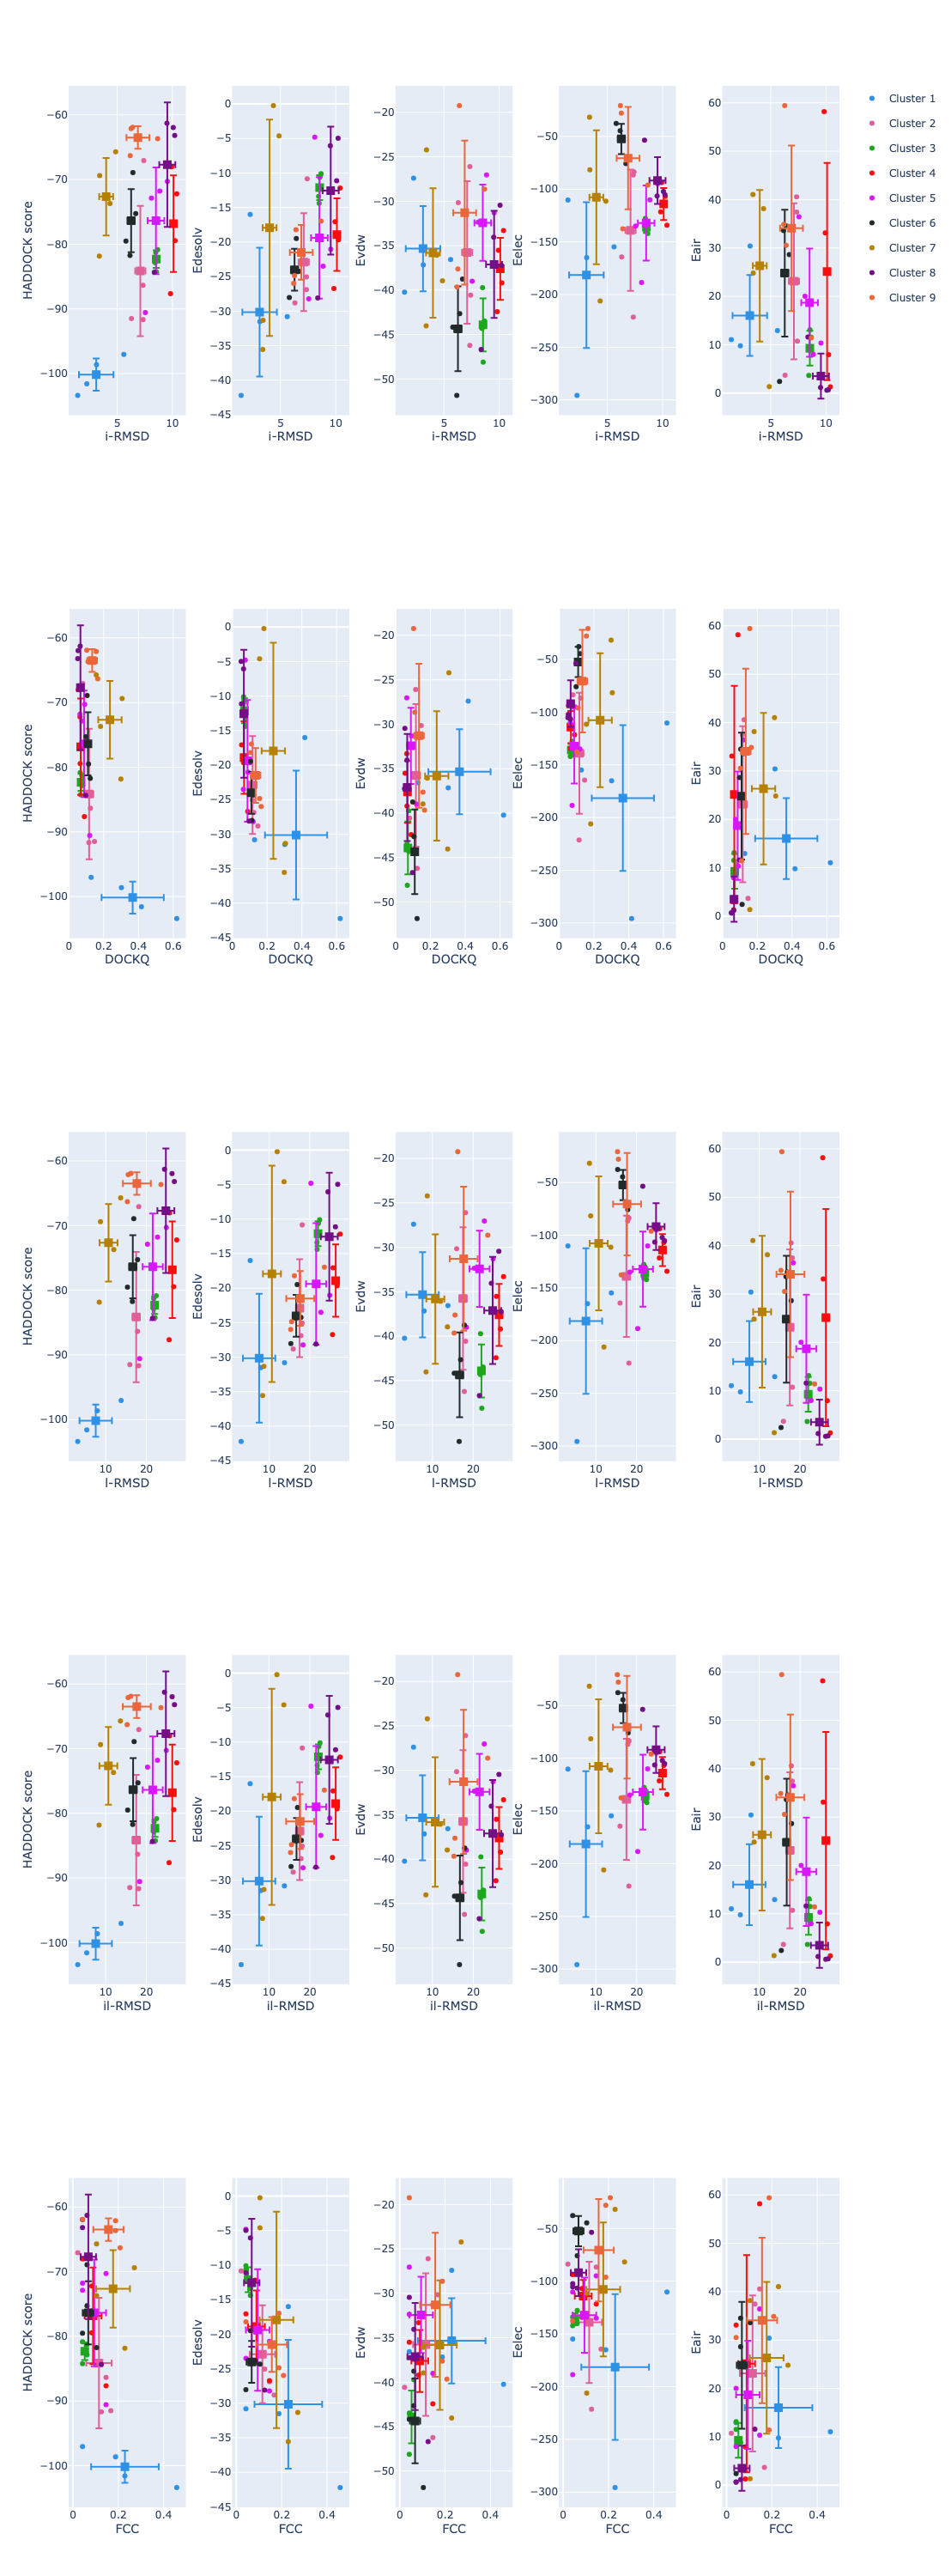

In [64]:
#@title View the various statistics plots
import json
import re
from IPython.display import display
import pandas as pd

# Specify the path to your HTML file
html_file_path = PROJECT_DIR  / "runs" / "run1" / "analysis" / "13_caprieval_analysis/report.html"

# Read the HTML file
with open(html_file_path, 'r') as f:
    html_content = f.read()

# Use a regular expression to find the script tag with id="data1" and extract its content
match_plot = re.search(r'<script id="data1" type="application/json">\s*(.*?)\s*</script>', html_content, re.DOTALL)

if match_plot:
    json_data_str_plot = match_plot.group(1)
    # Load the JSON data
    plot_data = json.loads(json_data_str_plot)

    # Set width and height to None to make the plot responsive
    if 'layout' in plot_data:
        plot_data['layout']['width'] = None
        #plot_data['layout']['height'] = None

    # Display the plot using iplot
    iplot(plot_data)
else:
    print("Could not find the script tag with id='data1' in the HTML file.")


Depending on the docking models, there could be a set of unclustered models. It will be explicitly shown in `report.html` as ‘other’. You can see the origins of these models in `traceback/traceback.tsv`.

Finally, the report also shows plots of the cluster statistics (distributions of values per cluster ordered according to their HADDOCK rank).

To view those distribution plots execute the next cell.



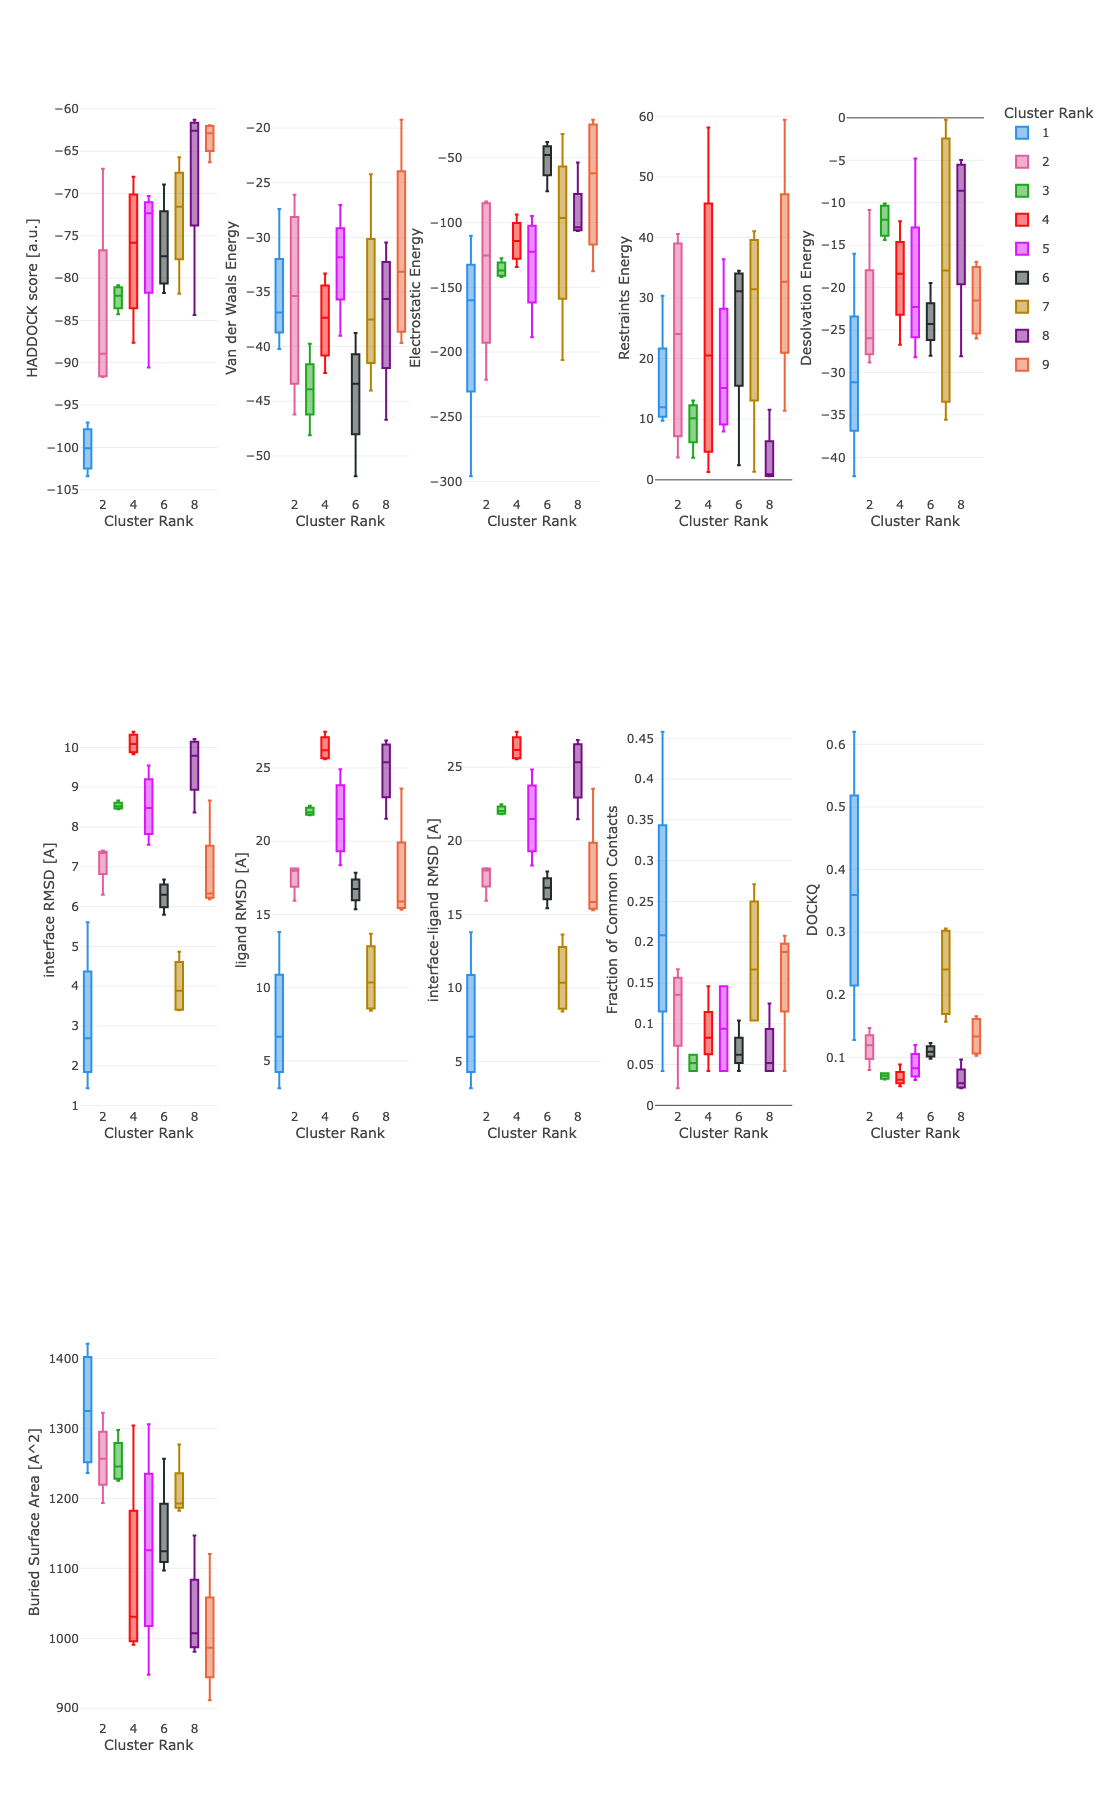

In [65]:
#@title View the various distribution plots
import json
import re
from plotly.offline import iplot

html_file_path = PROJECT_DIR / "runs" / "run1" / "analysis" / "13_caprieval_analysis" / "report.html"

with open(html_file_path, 'r') as f:
    html_content = f.read()

match_plot = re.search(r'<script id="data2" type="application/json">\s*(.*?)\s*</script>', html_content, re.DOTALL)

if match_plot:
    json_data_str_plot = match_plot.group(1)
    plot_data = json.loads(json_data_str_plot)

    if 'layout' in plot_data:
        plot_data['layout']['width'] = None
        # Remove the template entirely — it contains deprecated trace types
        # (e.g. heatmapgl) that newer plotly versions no longer recognize
        plot_data['layout'].pop('template', None)

    iplot(plot_data, validate=False)
else:
    print("Could not find the script tag with id='data1' in the HTML file.")

__*Examine report.html for one of the unclustered steps. Are any of the top-10 models as good as cluster_1_model_1 based on their iRMSD?*__

# Detailed information about models and clusters

To extract most of the avalilable information about the model(s), one should look at the `XX_caprieval` directories. This directory will always contain a `capri_ss.tsv` file, which contains the model names, rankings and statistics, e.g. `11_caprieval/capri_ss.tsv`:

```
model	md5	caprieval_rank	score	irmsd	fnat	lrmsd	ilrmsd	dockq	rmsd	cluster_id	cluster_ranking	model-cluster_ranking	air	angles	bonds	bsa	cdih	coup	dani	desolv	dihe	elec	improper	rdcs	rg	sym	total	vdw	vean	xpcs
../05_emref/emref_280.pdb	-	1	-103.403	1.437	0.458	3.139	3.184	0.620	1.249	1	1	1	11.045	66.508	10.291	1266.690	0.000	0.000	0.000	-42.226519.082	-110.279	13.374	0.000	0.000	0.000	-139.461	-40.226	0.000	0.000
../05_emref/emref_331.pdb	-	2	-101.588	2.256	0.229	5.365	5.385	0.417	1.941	1	1	2	9.775	64.115	13.897	1420.890	0.000	0.000	0.000	-16.012541.892	-295.776	16.619	0.000	0.000	0.000	-313.399	-27.398	0.000	0.000
../05_emref/emref_195.pdb	-	3	-98.641	3.134	0.188	7.947	7.992	0.302	2.658	1	1	3	30.399	59.802	10.347	1236.320	0.000	0.000	0.000	-31.515	541.989-164.995	13.680	0.000	0.000	0.000	-171.762	-37.167	0.000	0.000
../05_emref/emref_87.pdb	-	4	-97.050	5.607	0.042	13.802	13.778	0.128	4.714	1	1	4	12.931	66.559	10.655	1383.200	0.000	0.000	0.000	-30.812	534.429-154.782	15.061	0.000	0.000	0.000	-178.425	-36.575	0.000	0.000
../05_emref/emref_535.pdb	-	5	-91.671	7.347	0.125	18.121	18.097	0.115	6.173	8	2	1	37.430	56.527	10.334	1267.570	0.000	0.000	0.000	-25.055	530.791-221.283	12.885	0.000	0.000	0.000	-209.955	-26.103	0.000	0.000
../05_emref/emref_516.pdb	-	6	-91.505	6.299	0.167	15.940	15.926	0.147	5.332	8	2	2	3.678	59.310	10.443	1193.220	0.000	0.000	0.000	-28.827	523.618-164.442	14.663	0.000	0.000	0.000	-190.921	-30.157	0.000	0.000
../05_emref/emref_969.pdb	-	7	-90.572	7.556	0.146	18.350	18.325	0.120	6.340	5	5	1	36.431	56.119	9.840	1306.030	0.000	0.000	0.000	-28.212	528.441-135.020	14.626	0.000	0.000	0.000	-137.588	-38.999	0.000	0.000
../05_emref/emref_271.pdb	-	8	-89.669	3.531	0.104	9.525	9.502	0.233	3.053	1	1	5	3.724	65.185	10.717	1142.830	0.000	0.000	0.000	-29.924	520.532-70.314	14.768	0.000	0.000	0.000	-112.645	-46.054	0.000	0.000
../05_emref/emref_852.pdb	-	9	-87.644	9.828	0.146	25.599	25.541	0.089	8.298	3	4	1	58.163	55.462	10.341	1304.070	0.000	0.000	0.000	-26.725	526.028-121.548	12.783	0.000	0.000	0.000	-105.811	-42.426	0.000	0.000
...
```

In case where the caprieval module was called after a clustering step, an additional `capri_clt.tsv` file will be present in the directory. This file contains the cluster ranking and score statistics, averaged over the minimum number of models defined for clustering (4 by default), with their corresponding standard deviations, e.g. `11_caprieval/capri_clt.tsv`:

```
cluster_rank	cluster_id	n	under_eval	score	score_std	irmsd	irmsd_std	fnat	fnat_std	lrmsd	lrmsd_std	dockq	dockq_std	ilrmsd	ilrmsd_std	rmsd	rmsd_std	air	air_std	bsa	bsa_std	desolv	desolv_std	elec	elec_std	total	total_std	vdw	vdw_std	caprieval_rank
1	1	125	-	-100.170	2.477	3.108	1.562	0.229	0.150	7.563	3.983	0.367	0.179	7.585	3.960	2.640	1.297	16.037	8.367	1326.775	77.191	-30.141	9.327	-181.458	69.133	-200.762	66.680	-35.341	4.791	1
2	8	5	-	-84.151	10.090	7.100	0.463	0.115	0.056	17.505	0.912	0.117	0.024	17.503	0.917	5.970	0.369	23.103	16.128	1257.242	46.358	-22.902	7.088	-139.000	57.498	-151.657	49.813	-35.759	8.016	2
3	2	16	-	-82.312	1.350	8.538	0.082	0.052	0.010	22.035	0.263	0.071	0.004	22.085	0.274	7.229	0.078	9.269	3.596	1253.533	28.777	-12.127	1.805	-135.983	5.649	-170.630	2.214	-43.916	2.976	3
4	3	11	-	-76.833	7.460	10.099	0.229	0.089	0.037	26.372	0.764	0.068	0.013	26.323	0.764	8.541	0.203	25.125	22.462	1089.075	126.968	-18.911	5.253	-114.106	15.228	-126.594	27.678	-37.614	3.485	4
5	5	8	-	-76.379	8.245	8.514	0.753	0.094	0.052	21.566	2.476	0.088	0.021	21.533	2.461	7.179	0.662	18.685	11.196	1126.436	129.493	-19.390	8.808	-132.176	35.568	-145.914	32.684	-32.423	4.286	5
6	4	9	-	-76.368	4.881	6.269	0.328	0.068	0.023	16.667	0.891	0.110	0.009	16.736	0.899	5.301	0.268	24.795	13.112	1150.585	62.269	-24.017	3.038	-52.364	14.345	-71.926	11.076	-44.357	4.763	6
7	6	7	-	-72.663	6.002	4.009	0.629	0.177	0.074	10.705	2.214	0.236	0.067	10.682	2.189	3.427	0.548	26.332	15.668	1211.172	38.298	-17.933	15.664	-107.707	63.530	-117.197	64.538	-35.821	7.280	7
8	7	7	-	-67.701	9.637	9.540	0.728	0.068	0.034	24.795	2.084	0.066	0.018	24.756	2.102	8.109	0.624	3.507	4.671	1035.520	65.979	-12.564	9.268	-91.881	22.162	-125.484	21.545	-37.111	6.027	8
9	9	4	-	-63.502	1.756	6.879	1.034	0.156	0.067	17.669	3.435	0.134	0.028	17.629	3.433	5.860	0.923	34.061	17.099	1001.322	75.611	-21.500	3.965	-70.569	48.643	-67.802	52.681	-31.294	8.104	9
```

In this file you find the cluster rank (which corresponds to the naming of the clusters in the previous `seletop` directory), the cluster ID (which is related to the size of the cluster, 1 being always the largest cluster), the number of models (column `n`) in the cluster and the corresponding statistics (averages + standard deviations).

These simple text files can be somewhat cumbersome to read “as-is”, but they can be easily manipulated using command line. The following commands will extract the best 3 models based on the DockQ score:


In [67]:
%cd runs/

/Users/eceokur/Downloads/HADDOCK3-protein-peptide/runs


In [68]:
!sort -r -k9 run1/02_caprieval/capri_ss.tsv | head -4

model	md5	caprieval_rank	score	irmsd	fnat	lrmsd	ilrmsd	dockq	rmsd	cluster_id	cluster_ranking	model-cluster_ranking	air	angles	bonds	bsa	cdih	coup	dani	desolv	dihe	elec	improper	rdcs	rg	sym	total	vdw	vean	xpcs
../01_rigidbody/rigidbody_51.pdb	-	3	-45.820	1.820	0.292	4.525	4.543	0.492	1.555	-	-	-	81.581	751.737	196.085	986.491	0.000	0.000	0.000	-33.082	479.547	-3.596	564.742	0.000	0.000	0.000	68.631	-9.354	0.000	0.000
../01_rigidbody/rigidbody_246.pdb	-	4	-45.793	1.774	0.250	4.393	4.414	0.485	1.515	-	-	-	121.731	751.736	196.081	998.318	0.000	0.000	0.000	-33.246	479.547	-3.714	564.742	0.000	0.000	0.000	111.417	-6.600	0.000	0.000
../01_rigidbody/rigidbody_146.pdb	-	2	-46.105	1.914	0.271	4.795	4.793	0.470	1.640	-	-	-	41.692	751.735	196.094	936.571	0.000	0.000	0.000	-33.651	479.547	-3.420	564.742	0.000	0.000	0.000	29.698	-8.574	0.000	0.000
sort: Broken pipe


# Performance analysis (when reference is available)

In case a reference structure is available, one may want to analyse the performance of the docking protocol, for example to count how many models of different quality were generated at each step of the workflow. This can be done with a simple bash script provided in `HADDOCK3-protein-peptide/scripts/`. This script extracts CAPRI statistics per model and reports the number of models of acceptable or better models from each `caprieval` steps. To use it, run the script with the path to the run directory you want to analyse as its argument:




In [69]:
%cd ..

/Users/eceokur/Downloads/HADDOCK3-protein-peptide


In [70]:
! bash ./scripts/extract-capri-stats.sh ./runs/run1

== ./runs/run1/02_caprieval/capri_ss.tsv
Total number of acceptable or better models:  391  out of  999
Total number of medium or better models:      295  out of  999
Total number of high quality models:          0  out of  999
 
awk: write error on /dev/stdout
 input record number 391, file 
 source line number 1
grep: stdout: Broken pipe
awk: write error on /dev/stdout
 input record number 391, file 
 source line number 1
grep: stdout: Broken pipe
awk: write error on /dev/stdout
 input record number 391, file 
 source line number 1
grep: stdout: Broken pipe
awk: write error on /dev/stdout
 input record number 391, file 
 source line number 1
grep: stdout: Broken pipe
awk: write error on /dev/stdout
 input record number 556, file 
 source line number 1
grep: stdout: Broken pipe
awk: write error on /dev/stdout
 input record number 556, file 
 source line number 1
grep: stdout: Broken pipe
awk: write error on /dev/stdout
 input record number 556, file 
 source line number 1
grep: stdout

__*Look at the single structure statistics. How does the quality of the best model change after flexible refinement? After final energy minimisation? Consider all 3 metrics*__.

*Note*: To extract similar statistics per cluster, use `scripts/extract-capri-stats-clt.sh`.


---
# Visualisation and comparison with the reference structure

It’s time to visualise some of the docking models! This part is not only nice and colorful, but also quite important. Model visualisation allows you to check whether the models look as expected, if the clusters well-defined, zoom in on the interface, etc.

To visualize the models from the top cluster of your favorite run, start PyMOL and load the cluster representatives you want to view, e.g. this could be the top models from cluster 1. These can be found in the `runs/run1/12_seletopclusts/` directory. Each run has a similar directory. Alternatively, in `analysis/XX_caprieval_analysis` you can find `summary.tgz` with either top-models of best clusters (decompress with `tar -xf summary.tgz`), or top-10 models among all unclustered ones.

If you want to get an impression of how well-defined a cluster is, repeat this for the best X models you want to view (cluster_1_model_X.pdb).

Load the reference structure `1YCR.pdb` from `pdbs/`. Alternatively, if reference has been used in `caprieval`, it can be found in corresponding `run1/data/XX_caprieval/`

In [78]:
from haddock.libs.libnotebooks import align_full
#@title View the top ranking model from the best cluster
#@markdown It will be shown superimposed onto the reference structure fitted only on the second receptor and the DNA
# Define paths to PDB files to be aligned
# Here we are overlaying the reference and 1st model from the 1st cluster
path1 = PROJECT_DIR / "runs" / "run1"/ "12_seletopclusts" / "cluster_1_model_1.pdb"
path2 = PROJECT_DIR / "pdbs" / "1YCR.PDB"

# Align molecules by chain and display the result.
# For the full alignement put all chain IDs in the `chains` variable.
align_full(str(path1), str(path2), chains = ['A'])

Error: File not found at /Users/eceokur/Downloads/HADDOCK3-protein-peptide/runs/run1/12_seletopclusts/cluster_1_model_1.pdb
Failed to load one or both PDB files


(<py3Dmol.view at 0x145435150>, None, {})

---
# BONUS: How to use ARCTIC-3D to predict interface residues?